<a href="https://colab.research.google.com/github/nmfairuz/ML-Coding/blob/main/Neural%20Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1 — Strengthen Neural Network Intuition

* Binary Classification Neural  Network
* Activation Function
 Experiment
 * Multiclass  Classification
 * Overfitting vs Underfitting Experiments

# 1. Binary Clasfication Neural Network:

0 = Fail
1 = Pass

We are using study hours + attendance as features to predict if someone is going to pass or fial the exam

## 1. Setting things up!

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense



## 2. Creating DataSet

In [ ]:
# Features:
# [study_hours, attendance]

X = np.array([
    [1, 30],
    [2, 35],
    [3, 40],
    [4, 50],
    [5, 55],
    [6, 60],
    [7, 70],
    [8, 75],
    [9, 85],
    [10, 95]
], dtype=np.float32)

# Labels:
# 0 = fail
# 1 = pass

y = np.array([
    0,
    0,
    0,
    0,
    1,
    1,
    1,
    1,
    1,
    1
], dtype=np.float32)

In [ ]:
X.shape

(10, 2)

10 training examples
2 features per example

In [ ]:
y.shape

(10,)

10 answers for 10 examples

## 3. Normalizing data

features are now:

Study hours: 1-10

attendace: 30-95

The difference is huge, so we will scale them to a reasonable level

In [ ]:
X=X/np.array([10,100]) # first col with get divided by it's max val, 2nnd by 2nd's max val
X

array([[0.1 , 0.3 ],
       [0.2 , 0.35],
       [0.3 , 0.4 ],
       [0.4 , 0.5 ],
       [0.5 , 0.55],
       [0.6 , 0.6 ],
       [0.7 , 0.7 ],
       [0.8 , 0.75],
       [0.9 , 0.85],
       [1.  , 0.95]])

Now the values are from 0 to 1

## 4. Build Neural network

In [ ]:
model=Sequential([
    Dense(4, activation='relu'),
    Dense(2, activation='relu'),
    Dense(1, activation='sigmoid'),
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

## 5. Saving History to plot

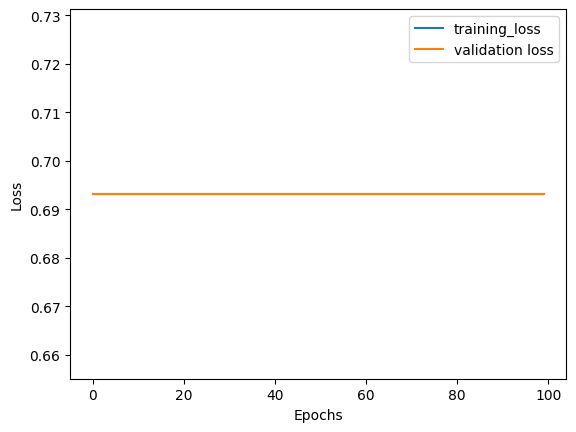

In [ ]:
plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 6. Predicting new data:

In [ ]:
new_student = np.array([[7, 80]], dtype=np.float32)

# normalize same way
new_student = new_student / np.array([10, 100])

prediction = model.predict(new_student)

print(prediction)
if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0.5]]
Pass


## Using A Denser Model

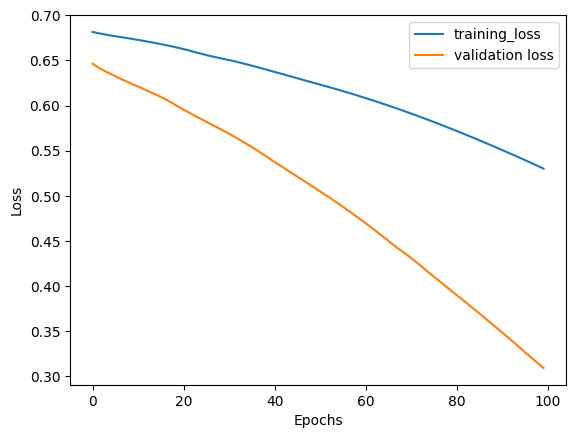

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.66160476]]
Pass


In [ ]:
model=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")


> With 10 training exmaples, model has only 2 examples to validate with, so Validation Error goes down but the training error doesnt come down that much!



# 2. Using Model with a bigger DataSet

In [ ]:
X = np.random.rand(200,2)
X[1]
# 0: study_hours + 1: attendance

# if study_hours + attendance is high -> pass
y = ((X[:,0] * 10 + X[:,1] * 100) > 60).astype(np.float32)

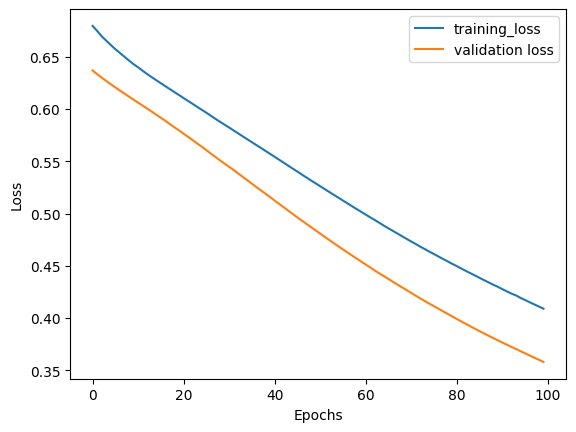

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.8765989]]
Pass


In [ ]:
model1=Sequential([
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model1.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model1.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

> It's decreasing Training Loss properly but not decreasing validation loss like that. -> Overfitting!

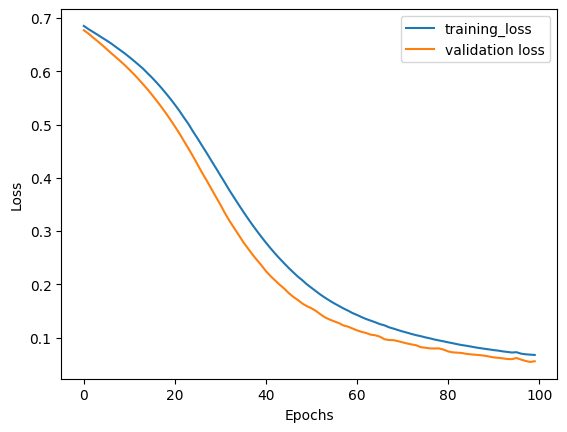

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.9980861]]
Pass


In [ ]:
model=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

This one is decreasing both Training Loss and Validation loss and even predicts 0.99 chance of passing -> much more confident and adapted well to both trianing and validation set, can work better for unseen data

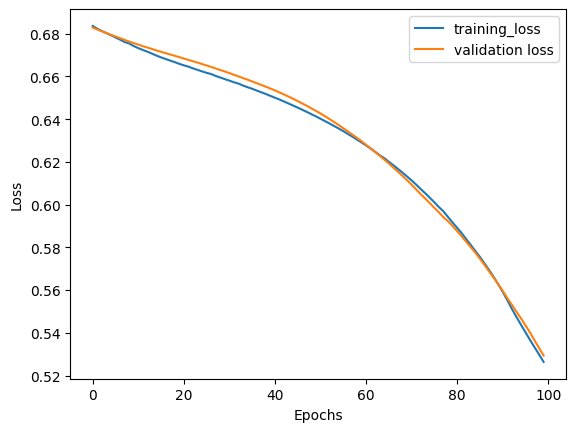

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


[[0.52039814]]
Pass
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[0.01193685]
 [0.04311919]
 [0.39038736]
 [0.99808604]
 [0.99982065]]


In [ ]:
model1=Sequential([
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model1.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model1.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

test_points = np.array([
    [1, 30],
    [3, 40],
    [5, 50],
    [7, 80],
    [10, 95]
], dtype=np.float32)

test_points = test_points / np.array([10,100])

print(model.predict(test_points))

> BOTH LOSS ENDS AT 0.5!! IT BARELY EVEN LEARN ANYTHING!

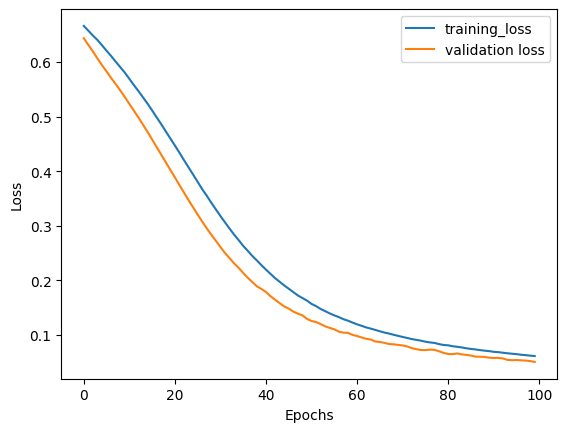

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.99896723]]
Pass
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.37640038]
 [0.39546436]
 [0.41485155]
 [0.52039814]
 [0.52039814]]


In [ ]:
model=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

plt.plot(history.history['loss'], label='training_loss')
plt.plot(history.history['val_loss'], label=['validation loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

test_points = np.array([
    [1, 30],
    [3, 40],
    [5, 50],
    [7, 80],
    [10, 95]
], dtype=np.float32)

test_points = test_points / np.array([10,100])

print(model1.predict(test_points))

Why Did Both Curves Start at ~0.7?

Binary crossentropy near:

0.693

is mathematically special.

Because:

sigmoid outputs near 0.5 initially
model starts uncertain/random

And:

−log(0.5)≈0.693

So:

~0.69 loss

basically means:

“the network is initially guessing randomly.”

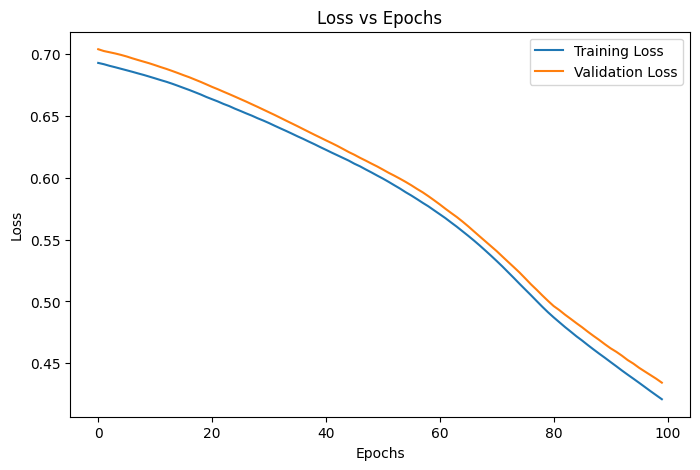

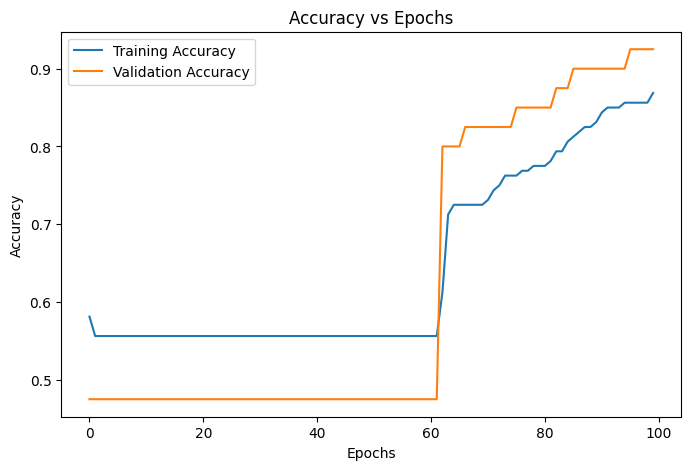

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[[0.54839605]]
Pass
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
[[0.00984677]
 [0.03093903]
 [0.35650367]
 [0.99896723]
 [0.9999496 ]]


In [ ]:
model1=Sequential([
    Dense(4, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model1.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

plt.legend()
plt.show()


# ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')

plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model1.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

test_points = np.array([
    [1, 30],
    [3, 40],
    [5, 50],
    [7, 80],
    [10, 95]
], dtype=np.float32)

test_points = test_points / np.array([10,100])

print(model.predict(test_points))


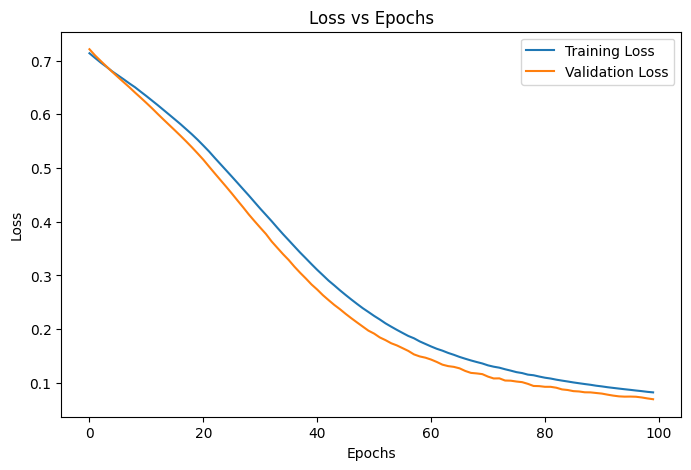

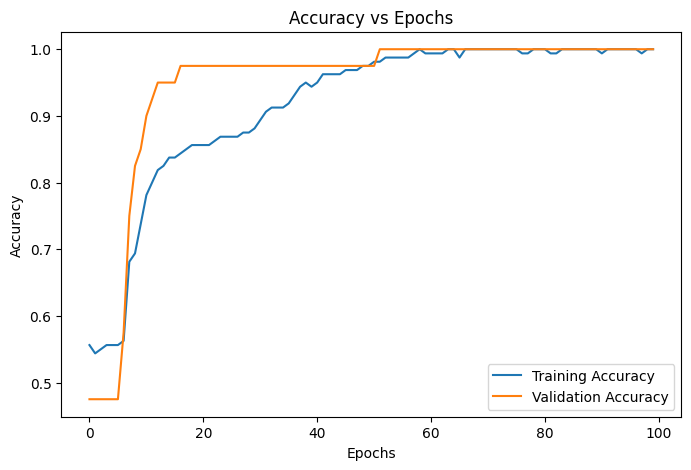

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
[[0.9876897]]
Pass
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.00984677]
 [0.03093903]
 [0.35650367]
 [0.99896723]
 [0.9999496 ]]


In [ ]:
model1=Sequential([
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history=model1.fit(
    X,y,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

# LOSS GRAPH

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')

plt.legend()
plt.show()


# ACCURACY GRAPH

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')

plt.legend()
plt.show()

new_student = np.array([[7, 80]], dtype=np.float32)
new_student = new_student / np.array([10, 100])
prediction = model1.predict(new_student)
print(prediction)

if prediction >= 0.5:
    print("Pass")
else:
    print("Fail")

test_points = np.array([
    [1, 30],
    [3, 40],
    [5, 50],
    [7, 80],
    [10, 95]
], dtype=np.float32)

test_points = test_points / np.array([10,100])

print(model.predict(test_points))


## Tweaks of ML:



At first it feels impossible:

> “If accuracy improves, shouldn’t loss decrease?”

Usually yes.

But not always.

And understanding WHY is a major milestone.

---

#### First Understand The Difference

##### Accuracy asks:

```text id="gq0t7h"
Was prediction correct or not?
```

ONLY that.

Example:

| Prediction | True Label | Accuracy |
| ---------- | ---------- | -------- |
| 0.51       | 1          | Correct  |
| 0.99       | 1          | Correct  |
| 0.5001     | 1          | Correct  |

All counted equally correct.

---

#### Loss asks:

```text id="lpfewx"
HOW confident was the prediction?
```

This is MUCH stricter.

Example:

| Prediction | True Label | Loss Quality |
| ---------- | ---------- | ------------ |
| 0.51       | 1          | weak         |
| 0.99       | 1          | excellent    |

Both accuracy = correct.

But loss says:

> “0.51 is still uncertain.”

---

#### Here’s The Key Scenario

Imagine 100 samples.

Initially:

| Correct            | Wrong            |
| ------------------ | ---------------- |
| 80 mild confidence | 20 mild mistakes |

Accuracy:

```text id="esb5aj"
80%
```

Loss:
moderate.

---

#### After More Training

Model becomes:

* VERY confident on correct samples
* BUT EXTREMELY confident on a few wrong samples

Now:

| Correct    | Wrong                     |
| ---------- | ------------------------- |
| 85 correct | 15 catastrophically wrong |

Accuracy improved:

```text id="uw94ej"
85%
```

BUT:

Those 15 wrong predictions might be like:

```text id="2b6mo0"
0.999 prediction for wrong class
```

Loss HATES this.

Because the model is:

> confidently wrong.

So:

* accuracy ↑
* loss ↑

YES, it can happen.

---

#### This Is SUPER Important In Real ML

Especially:

* imbalanced datasets
* overfitting
* medical ML
* fraud detection

A model that is:

```text id="tjlwm7"
confidently wrong
```

is dangerous.

---

#### Mathematical Intuition

Binary crossentropy heavily punishes:

```text id="j2b3mb"
prediction ≈ 1
when true label = 0
```

because:

-\log(1-p)

explodes when:

```text id="ifb8jw"
p → 1
```

So a few extremely bad predictions can dominate total loss.

---

#### Tiny Example

Suppose:

##### Model A

Predictions:

```text id="0q6ms5"
0.6 correct
0.6 correct
0.6 correct
0.4 wrong
```

Accuracy:

```text id="rzdj8g"
75%
```

Loss:
moderate.

---

##### Model B

Predictions:

```text id="4ph72n"
0.99 correct
0.99 correct
0.99 correct
0.999999 wrong
```

Accuracy:
still:

```text id="gv56tx"
75%
```

BUT loss becomes MUCH worse because:

* one prediction is catastrophically overconfident.

---

#### You Can ACTUALLY Create This Experiment

Here’s a fun one.

Train too aggressively.

Use:

```python id="0hgb9k"
learning_rate=1
```

or:

```python id="o5n9eo"
epochs=1000
```

Sometimes you’ll observe:

* accuracy plateaus/improves
* loss becomes unstable or rises

because confidence becomes extreme.

---

#### Biggest Takeaway

Accuracy measures:

```text id="jlwm1w"
correctness
```

Loss measures:

```text id="cz0ob4"
quality/confidence of predictions
```

Loss is a much richer signal.

That’s why:

* ML engineers monitor loss carefully
* not accuracy alone

This distinction becomes HUGE later in deep learning.


# 3. Multiclass Classification

We are going to using Fashing MNIST as dataset and we will classify shirts, shoes, bags, trousers, etc


## 1. Loading DataSet

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

In [ ]:
X_train[5]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,  22,  88, 188, 172,
        132, 125, 141, 199, 143,   9,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,  20, 131, 199, 206, 196, 202, 242,
        255, 255, 250, 222, 197, 206, 188, 126,  17,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,  35, 214, 191, 183, 178, 175, 168, 150,
        162, 159, 152, 158, 179, 183, 189, 195, 185,  82,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 170, 190, 172, 177, 176, 171, 169, 162,
        155, 148, 154, 169, 174, 175, 175, 177, 183, 188,  12,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  25, 194, 180, 178, 174, 184, 187, 189, 187,
        184, 181, 189, 200, 197, 193, 190, 178, 175, 194,  90,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  42, 218, 191, 197, 208, 204, 211, 209, 210,
        212, 211, 214, 215, 213, 214, 211, 211, 191, 200, 158,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  88, 221, 215, 217, 219, 211, 185, 150, 118,
        107,  99,  88,  83,  90, 135, 212, 203, 207, 219, 169,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  27, 118, 162,  40,   0,   0,   0,  10,
         19,  28,  39,  47,  36,   0,   0, 203, 230, 220, 203,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 138, 136,  71,  69,  54, 216, 217, 203, 184,
        168, 163, 162, 163, 178, 221, 186,  38,  26,   7,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  67, 134, 154, 224, 129,  66,  81, 117, 129,
        128, 132, 137, 131, 129,  86,  73, 157, 151, 134, 216,  18,   0,
          0,   0],
       [  0,   0,   0,   0, 203, 198, 172, 183, 206, 255, 255, 250, 243,
        240, 239, 235, 238, 244, 255, 238, 184, 160,  86,  98,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 122, 188, 224, 151, 105, 127,  97, 100, 105,
        114, 117, 117, 113, 103,  98, 111, 142, 254, 191, 255,  49,   0,
          0,   0],
       [  0,   0,   0,   0, 163, 179, 200,  95, 154, 198, 197, 200, 200,
        198, 197, 198, 199, 202, 200, 176,  86, 206, 157, 162,  10,   0,
          0,   0],
       [  0,   0,   0,   0, 197, 201, 229,  71, 144, 194, 181, 183, 179,
        182, 180, 179, 180, 190, 185, 197,  76, 219, 185, 201,  34,   0,
          0,   0],
       [  0,   0,   0,   0, 199, 193, 226,  58, 154, 192, 184, 187, 184,
        186, 184, 185, 183, 192, 191, 200,  56, 219, 203, 207,  60,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 194, 224,  41, 163, 190, 186, 186, 184,
        185, 183, 185, 178, 190, 194, 202,  33, 211, 200, 206,  73,   0,
          0,   0],
       [  0,   0,   0,   0, 201, 197, 222,  17, 172, 190, 186, 187, 182,
        186, 185, 187, 180, 187, 193, 202,  26, 212, 202, 203,  76,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 177, 189, 184, 185, 178,
        184, 183, 184, 180, 183, 189, 203,  35, 196, 203, 203,  84,   0,
          0,   0],
       [  0,   0,   0,   0, 200, 197, 223,   0, 185, 187, 185, 187, 180,
        184, 182, 183, 178, 182, 183, 205,  44, 159, 207, 201,  85,   0,
          0,   0],
       [  0,   0,   0,   0, 187, 198, 225,   0, 194, 188, 184, 185, 180,
        183, 183, 184, 181, 181, 177, 206,  46, 129, 211, 200,  88,   0,
          0,   0],
       [  0,   0,   0,   6, 186, 200, 211,   0, 199, 189, 184, 184, 185,
        182, 183, 184, 185, 182, 175, 205,  50,  97, 216, 197,  93,   0,
          0,   0],
       [  0,   0,   0,   5, 185, 204, 184,   0, 202, 188, 182, 182, 183,
        183, 184, 182, 180, 182, 174, 202,  63,  59, 220, 196,  94,   0,
          0,   0],
       [  0,   0,   0,   5, 184, 206, 157,   0, 204, 187, 187, 189, 192,
        190, 190, 191, 190, 187, 183, 202,  78,  35, 222, 197,  95,   0,
          0,   0],
       [  0,   0,   0,   5, 183, 208, 127,   0, 197, 166, 153, 149, 149,
        146, 148, 149, 150, 151, 158, 191,  90,   8, 223, 195,  99,   0,
          0,   0],
       [  0,   0,   0,   6, 184, 208, 11

In [ ]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


X_train -> 60000 images and 28px*28px

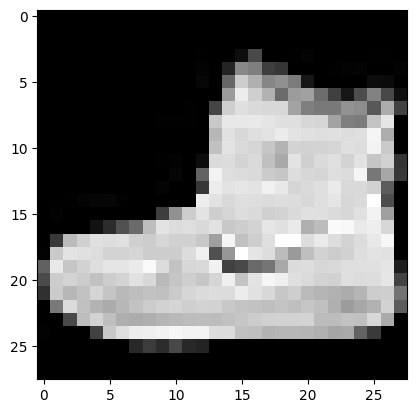

9


In [ ]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

print(y_train[0])


In [ ]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

Each image:

is just a matrix of numbers
pixel intensities:

0 → black

255 → white

## 2. Normalizing Data

Now pixels are 0-255, we will make them from 0 to 1

In [ ]:
X_train=X_train/255.0
X_test=X_test/255.0

## 3. Building Model

In [ ]:
model=Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    Dense(124, activation='relu'),
    Dense(10, activation='softmax'),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Flatten Layer

Images are:

28 × 28

But Dense layers expect:

1D vector

Flatten converts:

28×28 → 784

Output Layer
Dense(10, activation='softmax')

### Why 10?

Because:

10 clothing categories
Why Softmax?

### Softmax outputs:

probabilities for ALL classes

Example output:

[0.01, 0.02, 0.90, 0.01, ...]

Meaning:

90% probability class 2
2% probability class 1
etc.

AND:

all probabilities sum to 1


## 4. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Why Sparse Categorical Crossentropy?

Your labels are:

0,1,2,3,4...

NOT:

[0,0,1,0,0]

So we use:

>sparse_categorical_crossentropy

TensorFlow internally handles encoding.

### 5. Train

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    verbose=False
)

## 6. Evaluate

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8766 - loss: 0.3529
0.8766000270843506


Fashion MNIST usually gets:

~85–90%

with simple networks.

## 7. Make Predictions

In [ ]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
np.set_printoptions(suppress=True, precision=12)
print(predictions[0])

[0.00001818919  0.000000017188 0.000002678207 0.000000027908
 0.000002691411 0.0002088931   0.000021079595 0.015863571
 0.000004730087 0.98387814    ]


This shows the probability of something belonging to class 1 to 10.

Max Prob is class 10, 0.87 and 2nd most is 0.124. So, it's more likely belong to class 10.

## 8. Find Predicted Class

In [ ]:
predicted_class = np.argmax(predictions[0])

print(predicted_class)
print(y_test[0])

9
9


argmax means:

index of largest value

If:

[0.1, 0.2, 0.7]

Then:

argmax = 2

because:

0.7 is largest

## 9. Show Image + Prediction

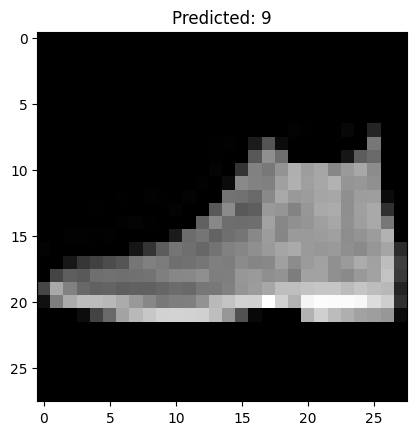

In [ ]:
plt.imshow(X_test[0], cmap='gray')
plt.title(f"Predicted: {predicted_class}")
plt.show()

## 10. Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[803   4  12  17   3   0 150   1  10   0]
 [  3 972   0  17   3   0   4   0   1   0]
 [ 12   1 709   9 140   0 117   0  12   0]
 [ 33  10  10 868  30   1  44   0   4   0]
 [  1   1  60  29 848   0  58   0   3   0]
 [  0   0   0   0   0 937   0  33   2  28]
 [100   0  48  21  84   0 728   0  19   0]
 [  0   0   0   0   0   5   0 952   1  42]
 [  5   0   0   3   3   1   2   4 982   0]
 [  0   0   0   0   0   3   1  29   0 967]]


### What Confusion Matrix Means

It shows:

> where model gets confused

Example:

* shirts mistaken as coats
* sandals mistaken as sneakers

This is REAL ML analysis.

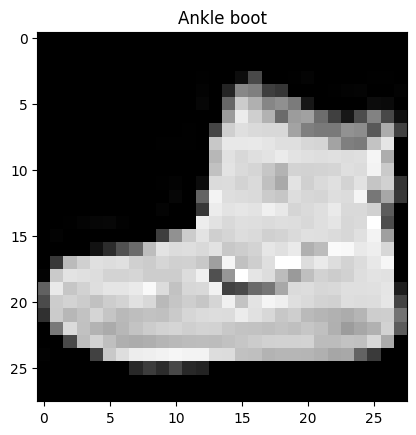

In [ ]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
plt.imshow(X_train[0], cmap='gray')
plt.title(class_names[y_train[0]])
plt.show()

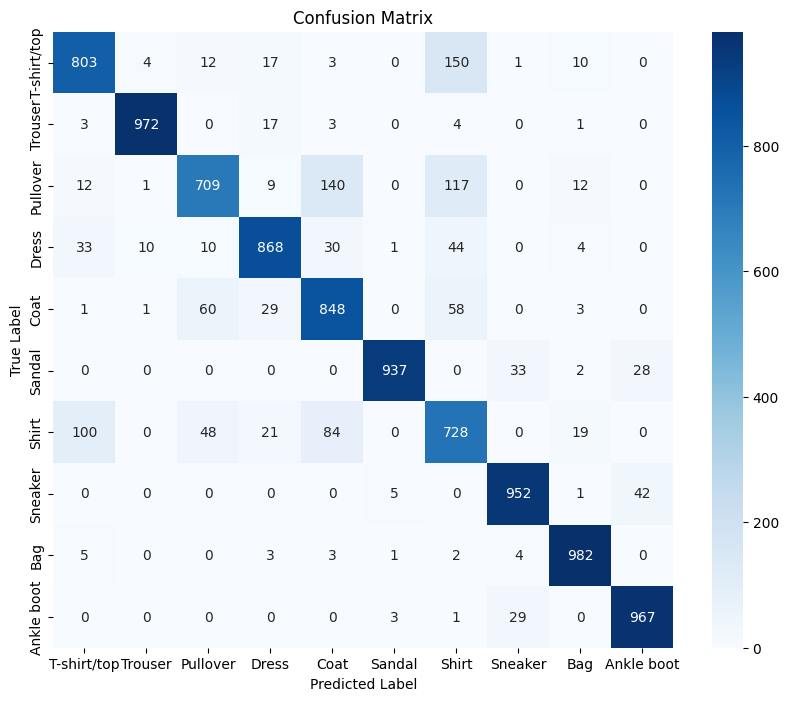

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

# 4. Overfitting vs Underfitting

#### 1. Imports

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

#### 2. Load Data

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

#### 3. Normalization

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

#### 4. Small DataSet

In [ ]:
X_trail_small=X_train[:1000]
y_trail_small=y_train[:1000]

#### 5. Using a Small Model

In [ ]:
tiny_model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(8, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


#### 6. Compile

In [ ]:
tiny_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### 7. Train the model

In [ ]:
tiny_history=tiny_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=10,
    validation_split=0.2,
    verbose=False
)

#### 8. Plot Function

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    #loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    #accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.show()

#### 9. Plot Tiny Model

In [ ]:
print(tiny_history.history)

{'accuracy': [0.2475000023841858, 0.3512499928474426, 0.44999998807907104, 0.53125, 0.5975000262260437, 0.606249988079071, 0.6312500238418579, 0.6549999713897705, 0.7012500166893005, 0.7337499856948853], 'loss': [2.0681815147399902, 1.7762260437011719, 1.5612993240356445, 1.3990081548690796, 1.2597019672393799, 1.1504220962524414, 1.0536866188049316, 0.9770013689994812, 0.9130575060844421, 0.8639695048332214], 'val_accuracy': [0.1850000023841858, 0.35499998927116394, 0.42500001192092896, 0.5049999952316284, 0.5550000071525574, 0.574999988079071, 0.5699999928474426, 0.6349999904632568, 0.675000011920929, 0.699999988079071], 'val_loss': [1.935886263847351, 1.7146447896957397, 1.5387938022613525, 1.3891990184783936, 1.2717738151550293, 1.1644805669784546, 1.0959324836730957, 1.0214810371398926, 0.9665448069572449, 0.9339736104011536]}


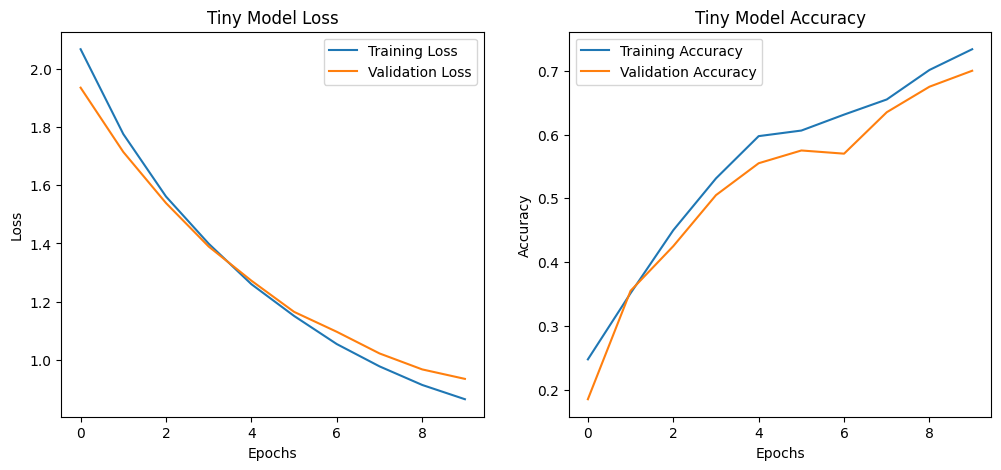

In [ ]:
plot_history(tiny_history, "Tiny Model")

Loss decreased

Meaning:

``` predictions improved over time. ```

Accuracy increased

Meaning:

``` model learned meaningful patterns. ```

BUT:

Loss still ending near: 1.0

is relatively high.


70%

accuracy for Fashion MNIST is mediocre.

This suggests:

``` UNDERFITTING ```

Meaning:

model is too weak/simple.

Exactly what we expected from:

Dense(8)

#### Using a Mid Model

In [ ]:
mid_model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=10,
    validation_split=0.2,
    verbose=False
)

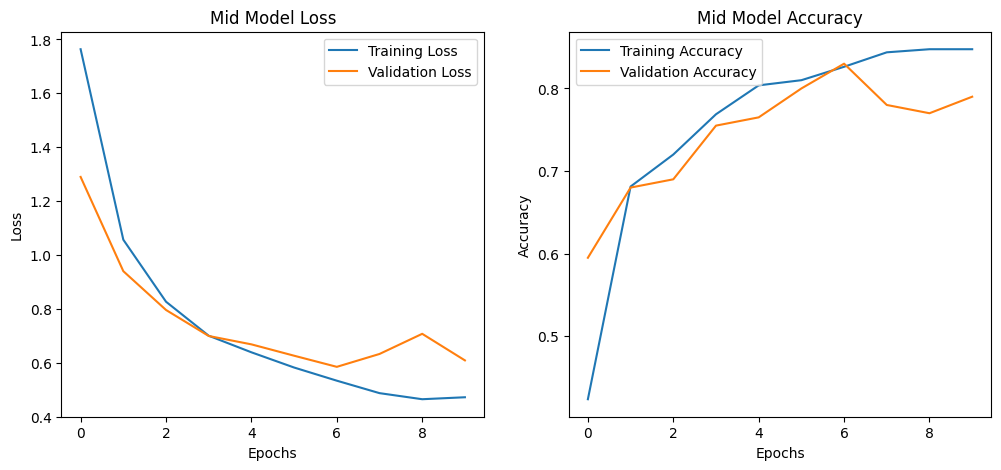

In [ ]:
plot_history(mid_history, "Mid Model")

Loss Came down for both

Training Set: 2 to 0.4

Validation Set: 1.65 to 0.6

Epoch is low, so it didn't get enough  repetition to learn from.

Accuracy:
Went upto 90% for Training Set and for Validation set it went upto 75%, not bad considering it didnt get enough repeatition.

##### With more epoch

In [ ]:
mid_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=200,
    validation_split=0.2,
    verbose=False
)

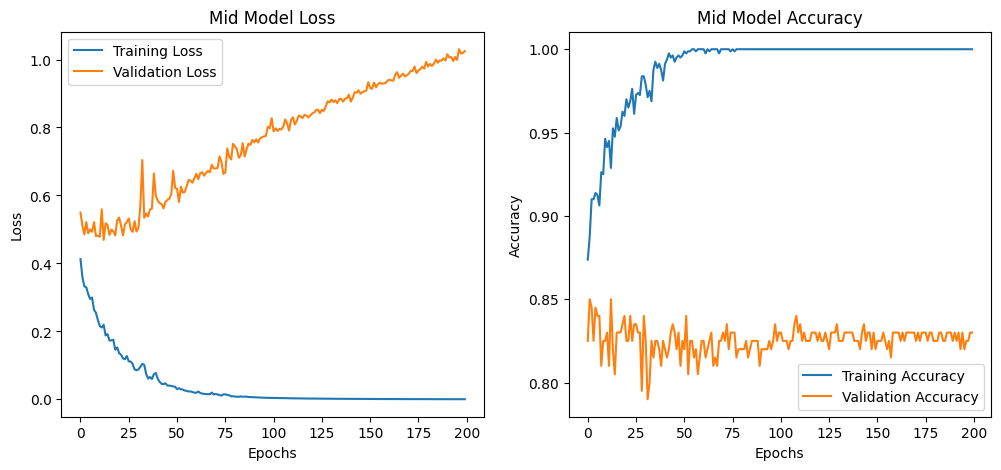

In [ ]:
plot_history(mid_history, "Mid Model")

We overfitted here by increasing epoch to 200, not both loss and accuracy got stuck for validation set.

Need to use lower epoch

More Epoch -> more repitition -> better learning

but what is it learning?

with lower and specific epoch, it's learning patterns, and with more epoch, it's memorizing examples from trianing set

#### Using mid level epoch, instead of hugeee

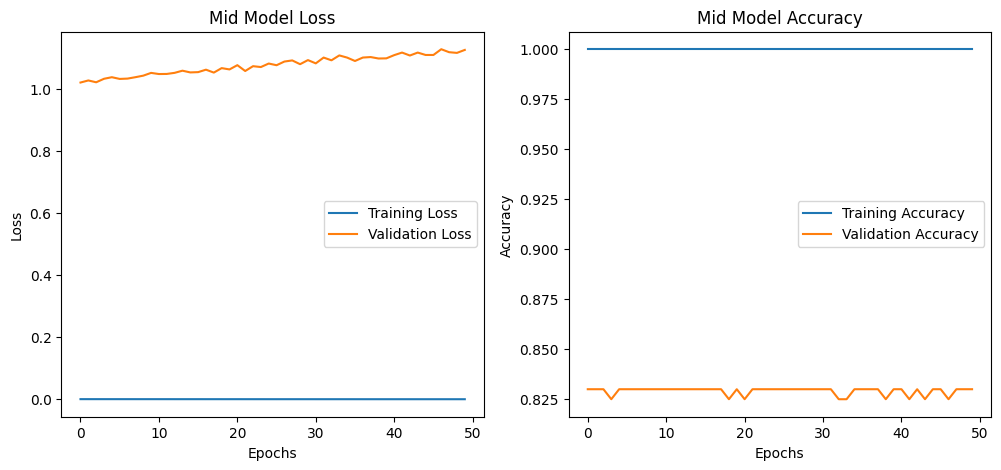

In [ ]:
mid_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(48, activation='relu'),
    Dense(24, activation='relu'),
    Dense(10, activation='softmax')
])
mid_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mid_history=mid_model.fit(
    X_trail_small,
    y_trail_small,
    epochs=50,
    validation_split=0.2,
    verbose=False
)
plot_history(mid_history,"Mid Model")

#### Larger model with smaller dataset

In [ ]:
X_trail_small=X_train[:100]
y_trail_small=y_train[:100]
huge_Model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(1080, activation='relu'),
    Dense(720, activation='relu'),
    Dense(480, activation='relu'),
    Dense(360, activation='relu'),
    Dense(10, activation='softmax')
])
huge_Model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
huge_history=huge_Model.fit(
    X_trail_small,
    y_trail_small,
    epochs=100,
    validation_split=0.2,
    verbose=False
)

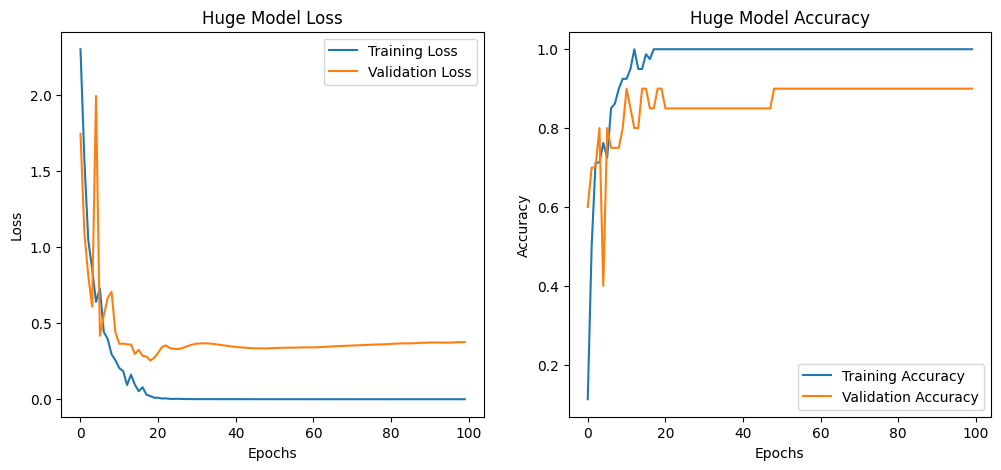

In [ ]:
plot_history(huge_history, "Huge Model")

Same here, model's accuracy and loss got stuck for validation set because it has a lot of neurons and it ended up memorizing examples form training set instead of finding general patterns. |

# Phase 2 — ML Debugging & Generalization

* Bias vs Variance Experiments
* Regularization Experiments
* Learning Curve Visualization
* Error Analysis

# 5. Bias vs Variance Practical Experiment

* Compare small vs large models.
* Observe high bias vs high variance behaviors.
* Study generalization performance.

| Concept  | Meaning                        |
| -------- | ------------------------------ |
| Bias     | model too simple               |
| Variance | model too sensitive/memorizing |


**High Bias** : Model assumptions are too restrictive.

```model cannot capture real patterns.```

Symptoms:

* train accuracy low
* validation accuracy low

Equivalent to:

``` underfitting ```

**High Variance** : Model adapts too much to training data.

Symptoms:

* train accuracy very high
* validation accuracy much worse

Equivalent to:

``` overfitting ```

## 1. Imports

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

## 2. Load Data

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

## 3. Normalize

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## 4. Smaller Dataset

In [ ]:
X_small = X_train[:1000]
y_small = y_train[:1000]

## 5. Plot func:

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    # ACCURACY
    plt.subplot(1,2,2)

    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')

    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

###  High Bias Model

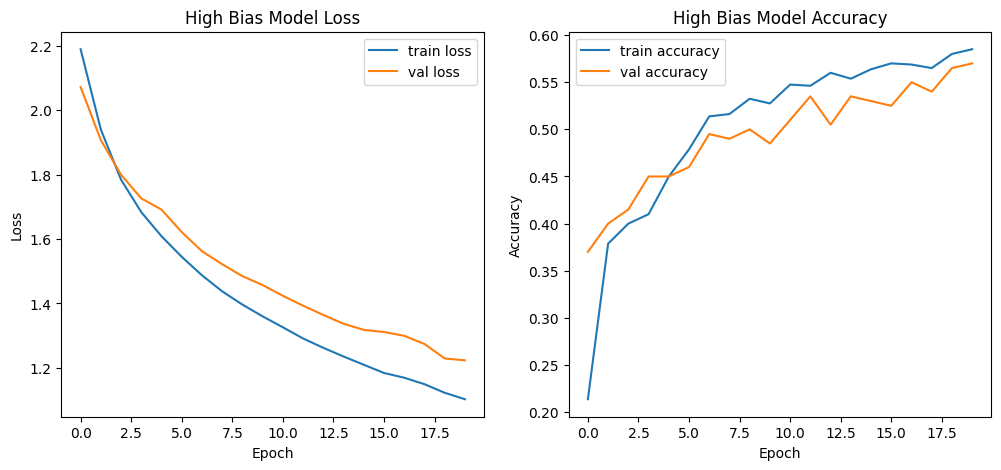

In [ ]:
bias_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(4, activation='relu'),

    Dense(10, activation='softmax')

])

bias_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bias_history = bias_model.fit(

    X_small,
    y_small,

    epochs=20,

    validation_split=0.2,

    verbose=False
)
plot_history(bias_history, "High Bias Model")

Loss Came down to 1 for VS and 0.6 for TS

But

Accuraty is 0.65 for TS and 0.55 for VS

has high Bias

### Balanced Model


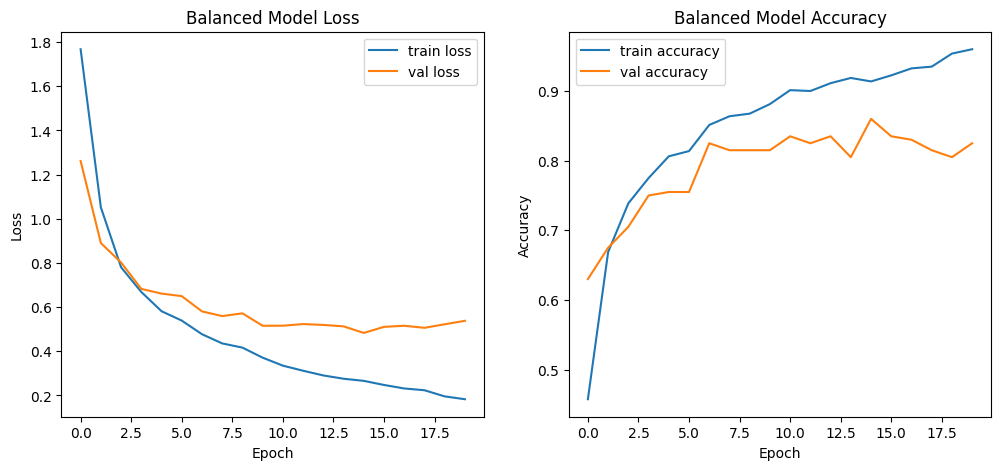

In [ ]:
balanced_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(

    X_small,
    y_small,

    epochs=20,

    validation_split=0.2,

    verbose=False
)
plot_history(balanced_history, "Balanced Model")

Training loss came down to 0.1 but Validation loss is about 0.6.

Accuracy comes to 1 for Training set, but for validation set, it's only 0.8

| Situation            | Training Error | Validation Error | Interpretation |
| -------------------- | -------------- | ---------------- | -------------- |
| High Bias            | high           | similar/high     | underfitting   |
| High Variance        | low            | much higher      | overfitting    |
| High Bias + Variance | high           | MUCH higher      | both problems  |


> Validation Loss is wayy Higher than then Training loss, we have a variance here!

Trying a simpler model!

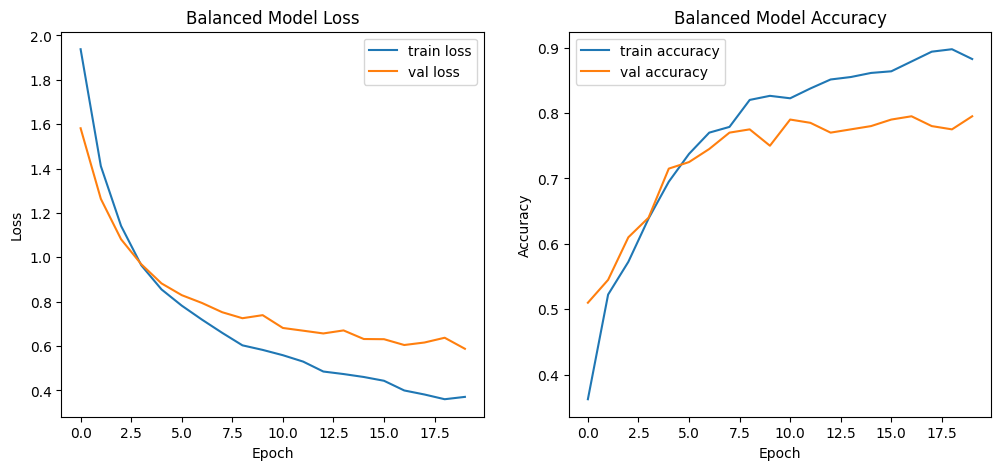

In [ ]:
balanced_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(30, activation='relu'),

    Dense(16, activation='relu'),

    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(

    X_small,
    y_small,

    epochs=20,

    validation_split=0.2,

    verbose=False
)
plot_history(balanced_history, "Balanced Model")

Simpler model is doing a bit better, lets try even simpler model.

btw, we are using 1000 rows only. So, simple model will fit better than a hugeee model!

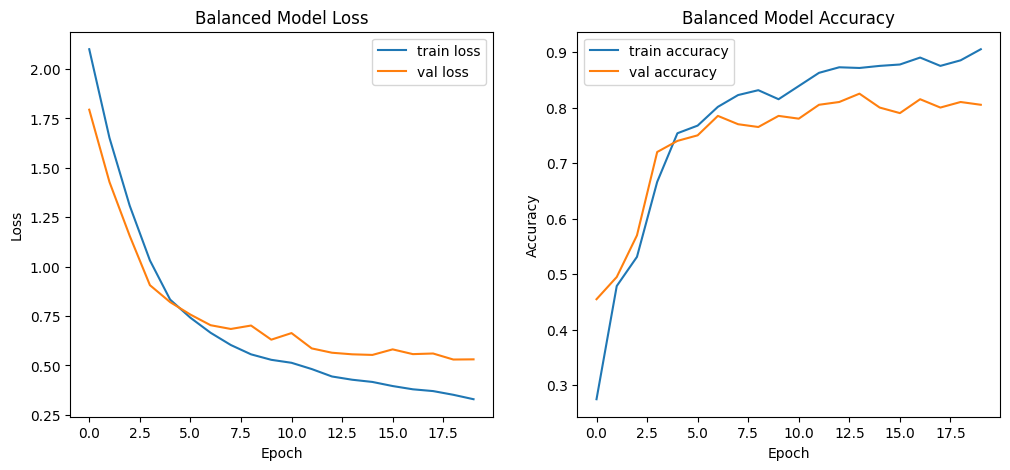

In [ ]:
balanced_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(24, activation='relu'),

    Dense(16, activation='relu'),

    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(

    X_small,
    y_small,

    epochs=20,

    validation_split=0.2,

    verbose=False
)
plot_history(balanced_history, "Balanced Model")

It didnt improve much, let's try with less epoch!

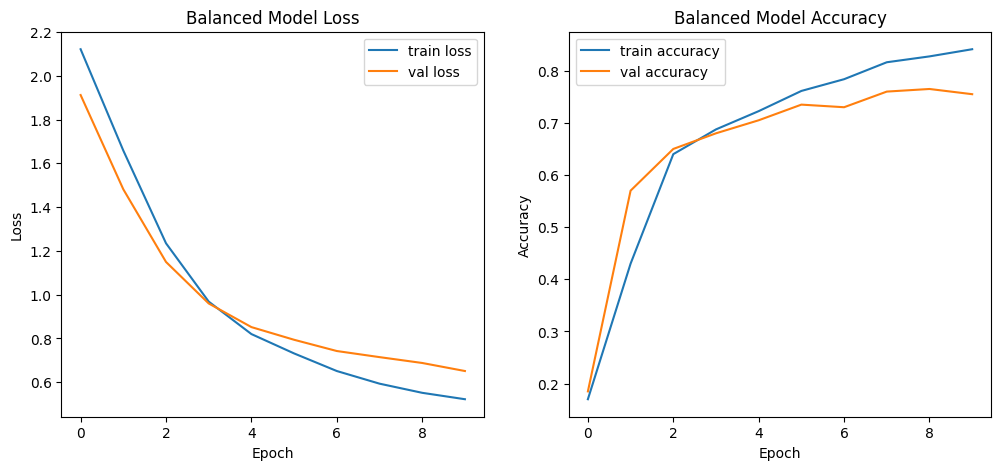

In [ ]:
balanced_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(24, activation='relu'),

    Dense(16, activation='relu'),

    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(

    X_small,
    y_small,

    epochs=10,

    validation_split=0.2,

    verbose=False
)
plot_history(balanced_history, "Balanced Model")

> Performance isn't improving much even with simpler model or with less epoch.

It's high variance issue, lets try with
* more data
* smaller set of features
* increase lambda

for this case, getting more data is possible, so lets try that!

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


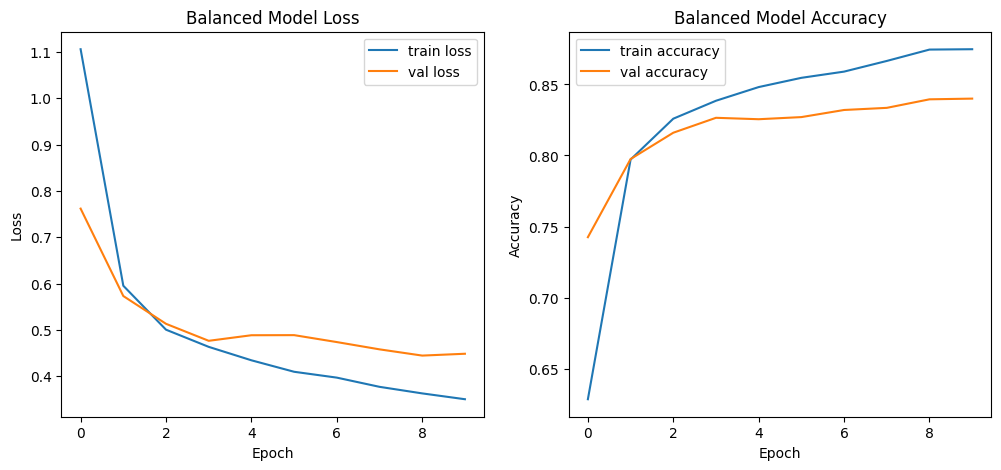

In [ ]:
X_mid=X_train[:10000]
y_mid=y_train[:10000]

balanced_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(24, activation='relu'),

    Dense(16, activation='relu'),

    Dense(10, activation='softmax')

])

balanced_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

balanced_history = balanced_model.fit(

    X_mid,
    y_mid,

    epochs=10,

    validation_split=0.2,

    verbose=False
)
plot_history(balanced_history, "Balanced Model")

#### Explaination:



More data reduced variance.


##### Compare Your Results


##### Before (1000 samples)

| Metric              | Result |
| ------------------- | ------ |
| Validation Loss     | ~0.7   |
| Validation Accuracy | ~0.75  |

---


##### Now (10000 samples)

| Metric              | Result |
| ------------------- | ------ |
| Validation Loss     | ~0.45  |
| Validation Accuracy | ~0.82  |

That’s a significant improvement.

---

#### And Notice Something VERY Important

You changed:

```text id="jlwmm1"
ONLY the dataset size
```

You did NOT change:

* optimizer
* architecture
* activation
* epochs

That isolates the effect clearly.

This is GOOD experimentation practice.

---

#### What Happened Internally

With only:

```text id="jlwmm2"
1000 samples
```

the model could:

* partially memorize
* learn unstable patterns
* overfit quickly

---

With:

```text id="jlwmm3"
10000 samples
```

the model sees:

* more diversity
* more clothing variations
* more examples of each class

So memorization becomes harder.

The network is forced to learn:

#### broader/general patterns.

---

#### THIS Is The Core Variance Insight

Variance often comes from:

```text id="jlwmm4"
model too dependent on specific training examples
```

More data reduces this dependence.

Beautiful ML concept honestly.

---

#### Another VERY Important Observation

Your validation accuracy improved:

```text id="jlwmm5"
75% → 82%
```

without increasing model complexity.

This is HUGE.

Because beginners often think:

```text id="jlwmm6"
“better performance = bigger network”
```

But many times:

#### better data > bigger model

This becomes extremely important later in AI/ML.

---

#### Your Validation Loss Also Improved

```text id="jlwmm7"
0.7 → 0.45
```

Meaning:

* predictions became more confident
* fewer confidently wrong outputs
* generalization improved

---

#### THIS Is Exactly Andrew’s Advice

For high variance:

* more data
* regularization
* smaller network
* early stopping

You experimentally confirmed:

#### more data worked.

That’s valuable intuition.

#### Another Subtle But Important Thing

You likely still have SOME variance.

Probably:

* train accuracy still higher than validation
* train loss still lower

That’s normal.

Perfectly equal train/validation performance is rare.

The goal is:

#### manageable generalization gap.

Not:

```text id="jlwmm8"
exact equality
```



### High Variance Model


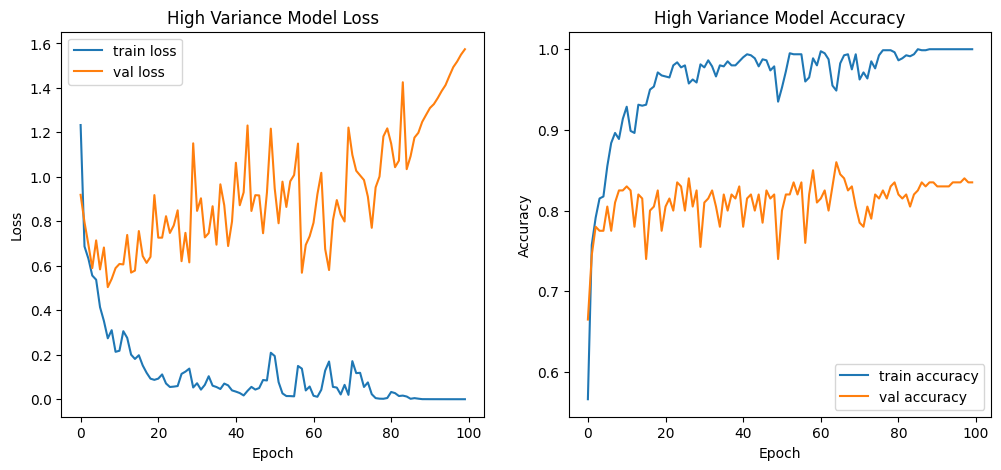

In [ ]:
variance_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(1024, activation='relu'),

    Dense(512, activation='relu'),

    Dense(256, activation='relu'),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')

])

variance_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

variance_history = variance_model.fit(

    X_small,
    y_small,

    epochs=100,

    validation_split=0.2,

    verbose=False
)
plot_history(variance_history, "High Variance Model")

Training Loss ~ 0 and Validation Loss Sky Rocketed!

``` High Variance! ```

# 6. Regularization Experiments

> **USE THIS WHEN U HAVE HIGH VARIANCE OR OVERFITTING!**

Because regularization:

> reduces model complexity/effective memorization.

* Implement Dropout layers.
* Implement L2 regularization.
* Compare performance before and after regularization.
* Observe validation improvements

Regularization means:

“Prevent the model from becoming overly specialized.”

| Method            | Idea                                     |
| ----------------- | ---------------------------------------- |
| Dropout           | randomly disable neurons during training |
| L2 Regularization | penalize large weights                   |


# Model Comparision:

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras import regularizers

## Load DataSet

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

## Using Smaller DataSet

In [ ]:
X_small = X_train[:1000]
y_small = y_train[:1000]

## Plot func:

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # LOSS
    plt.subplot(1,2,1)

    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')

    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    # ACCURACY
    plt.subplot(1,2,2)

    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')

    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

## Baseline Model (Model without regularization)

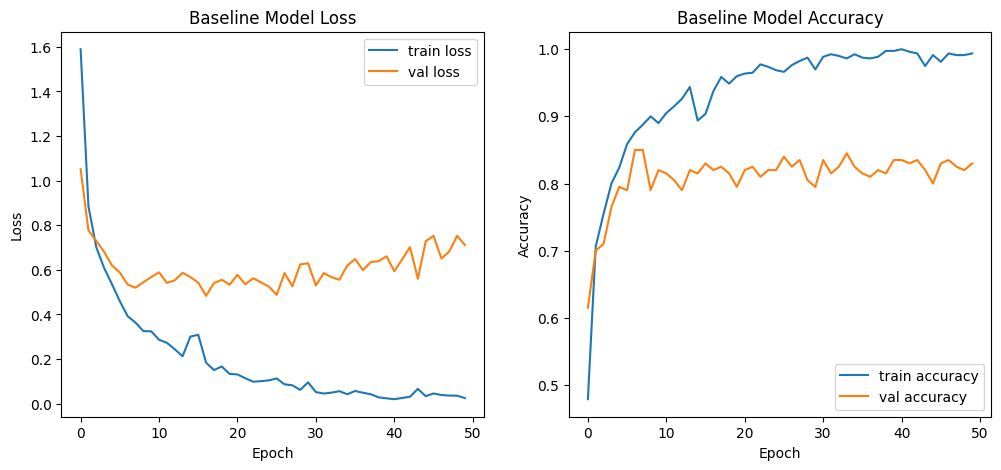

In [ ]:
baseline_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')

])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

baseline_history = baseline_model.fit(

    X_small,
    y_small,

    epochs=50,

    validation_split=0.2,

    verbose=False
)
plot_history(baseline_history, "Baseline Model")

For Training Set:

    Loss: 1.6 -> 0.01

    Accuracy: 0 -> 0.95

For Validation Set:

    Loss: 1 -> 0.75

    Accuracy: 0.6 -> 0.8

## Dropout Model:

What Dropout Does

During training:
 **randomly disables neurons**

Example:

``` dropout = 0.5 ```

means:

> 50% neurons randomly ignored each step.

WHY This Helps

Prevents:

* neurons becoming overly dependent on each other

Forces:

* more robust learning
* distributed representations
* less memorization

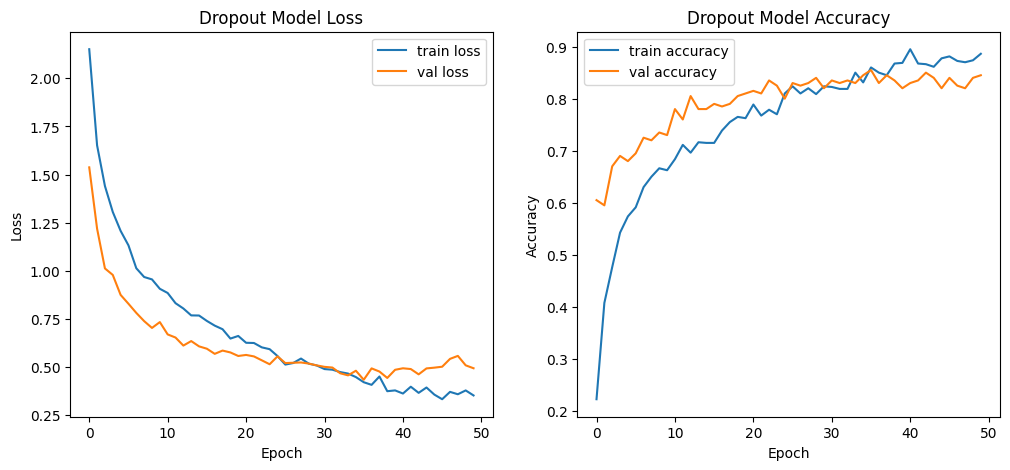

In [ ]:
dropout_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

dropout_history = dropout_model.fit(

    X_small,
    y_small,

    epochs=50,

    validation_split=0.2,

    verbose=False
)

plot_history(dropout_history, "Dropout Model")

For Training Set:

    Loss: 2.2 -> 0.3

    Accuracy: 0.2 -> 0.9

For Validation Set:

    Loss: 1.5 -> 0.6

    Accuracy: 0.6 -> 0.85

## L2 REGULARIZATION

What L2 Does

Adds penalty term:

``` Loss=Original Loss+λ∑w^2 ```

Meaning:

> large weights become expensive
model prefers smaller/smoother weights

WHY This Helps

Large weights often create:

* sharp decision boundaries
* unstable memorization

L2 encourages:

smoother/generalizable behavior

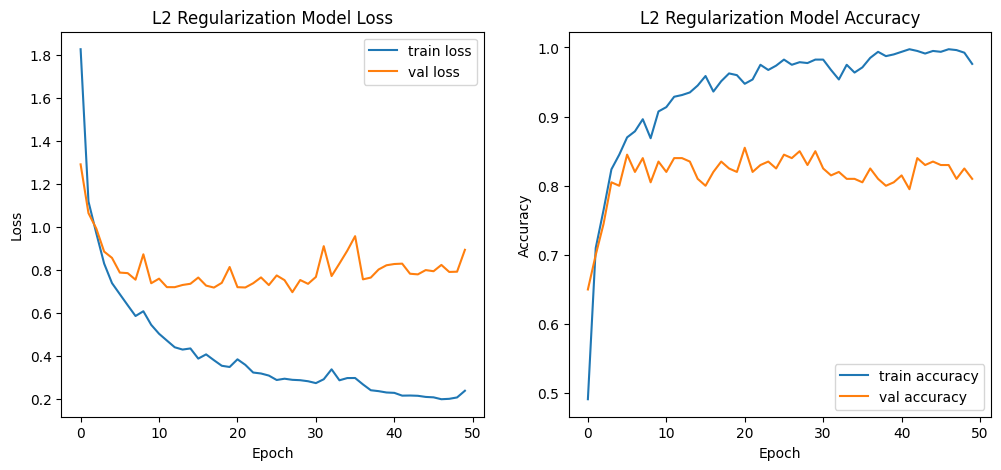

In [ ]:
l2_model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    Dense(10, activation='softmax')

])

l2_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

l2_history = l2_model.fit(

    X_small,
    y_small,

    epochs=50,

    validation_split=0.2,

    verbose=False
)

plot_history(l2_history, "L2 Regularization Model")

For Training Set:

    Loss: 1.8 -> 0.3

    Accuracy: 0.4 -> 0.98

For Validation Set:

    Loss: 1.3 -> 0.9

    Accuracy: 0.66 -> 0.8

For this model, L2 didn't do well, however, Dropout Model Regularization did pretty well.

If your model already cannot fit training data:

* Train accuracy low

* Validation accuracy low

then adding regularization usually makes it WORSE.

Because the model is already too weak.

That’s high bias.

But If:

* Train accuracy very high
* Validation much worse

then:

regularization becomes useful.


Workflow:
1. Train baseline model.

    No heavy regularization initially.

2. Diagnose:

    * bias?
    * variance?
    * data issue?
    * optimization issue?
    
    using:

    * train/validation curves
    * learning curves
    * metrics

3. Apply targeted fix.

    Not random fixes.


> **How do we know which regularization works better?**

Usually:

we try multiple approaches

and compare validation performance.


Industry Practice

People commonly test:

* no regularization
* dropout
* L2
* dropout + L2
* data augmentation
* early stopping


compare:

> validation/generalization performance.

> **Validation Set Is The Judge**

>regularization intentionally sacrifices training perfection

#### Practical Intuition About Methods

**Dropout:**

Usually useful when:

    * neural nets large
    * overfitting obvious
    * dataset relatively small

Especially common in:

    * dense layers
    * older CNN architectures
    * L2 Regularization

Usually useful when:

    * weights becoming extreme
    * smoother solutions desired
    * moderate overfitting

Very classical/general technique.

Early Stopping : EXTREMELY common.

```  If validation stops improving: stop training.  ```

Very effective and simple.

You independently reinvented this idea earlier.

**Data Augmentation:**

    Huge in computer vision.

Instead of collecting new data:

* rotate images
* flip images
* crop images
* add noise

Artificially increases diversity.

# 7. Error Analysis

* Display incorrectly predicted samples.
* Analyze WHY the model failed
* Develop debugging intuition

What Is Error Analysis?

Simple idea:

Instead of only looking at:

    accuracy
    loss
    confusion matrix

we directly inspect:

    the mistakes.

Meaning:

    Which samples did the model predict wrong?

and more importantly:

    WHY did it fail?

Because accuracy alone cannot tell:

    what patterns fail
    which classes confuse the model
    whether data itself is ambiguous
Error analysis reveals:

    model behavior.

Simple Error Analysis Workflow:

1. Predict on test set
2. Find incorrect predictions
3. Display images
4. Compare:
    true label
    predicted label
5. Look for patterns

| Observation               | Possible Meaning           |
| ------------------------- | -------------------------- |
| certain classes confused  | features overlap           |
| blurry images fail        | model sensitive to quality |
| rare styles fail          | insufficient data          |
| unusual orientations fail | lack of augmentation       |


In [ ]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

wrong_indices = np.where(predicted_labels != y_test)[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


## 1. Make Predictions:

In [ ]:
predictions = balanced_model.predict(X_test)

# predictions contains probability distributions
# Example:
# [0.01, 0.02, 0.7, 0.05, ...]


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
predictions

array([[0.000058088957, 0.000002007075, 0.000064166605, ...,
        0.090122744   , 0.0054400344  , 0.8667786     ],
       [0.00007497982 , 0.000002656676, 0.96377057    , ...,
        0.            , 0.000005215562, 0.000000000026],
       [0.000009279004, 0.9999626     , 0.000001122063, ...,
        0.000000000008, 0.000006978703, 0.            ],
       ...,
       [0.052967012   , 0.000022919457, 0.002064748   , ...,
        0.000030169265, 0.9213071     , 0.000002366278],
       [0.000001397687, 0.99963653    , 0.000000437909, ...,
        0.000000010659, 0.00000789655 , 0.            ],
       [0.00008081151 , 0.000011599333, 0.000064381864, ...,
        0.021953117   , 0.0041193534  , 0.00092689955 ]], dtype=float32)

## 2. We want the class with highest probability


In [ ]:
predicted_labels = np.argmax(predictions, axis=1)


In [ ]:
predicted_labels

array([9, 2, 1, ..., 8, 1, 5])

## 3. Find Wrong Predictions

In [ ]:
wrong_indices = np.where(predicted_labels != y_test)[0]

print("Total Wrong Predictions:", len(wrong_indices))

Total Wrong Predictions: 1671


## 4. Class Names

In [ ]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]


## 5. Display One Wrong Prediction


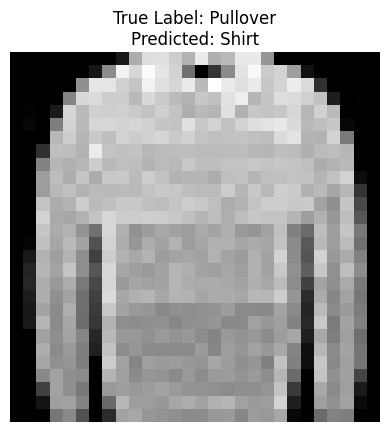

In [ ]:
index = wrong_indices[0]
plt.imshow(X_test[index], cmap='gray')
plt.title(

    f"True Label: {class_names[y_test[index]]}\n"
    f"Predicted: {class_names[predicted_labels[index]]}"

)

plt.axis('off')
plt.show()



## 6. Display Multiple Wrong Prediction

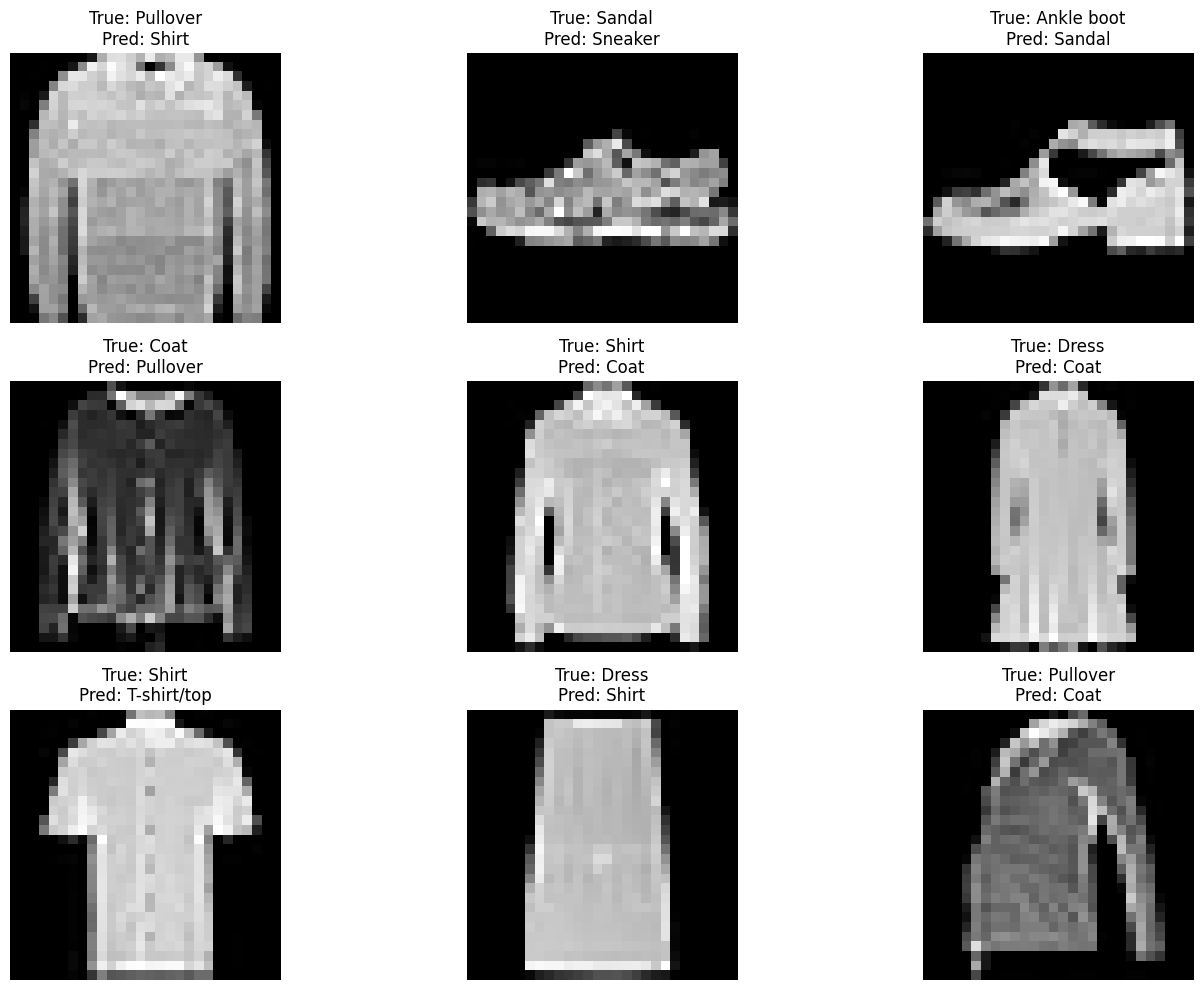

In [ ]:
plt.figure(figsize=(15,10))

for i in range(9):

    index = wrong_indices[i]

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[index], cmap='gray')

    plt.title(

        f"True: {class_names[y_test[index]]}\n"
        f"Pred: {class_names[predicted_labels[index]]}"

    )

    plt.axis('off')

plt.tight_layout()



| True Class | Predicted As |
| ---------- | ------------ |
| Pullover   | Shirt        |
| Coat       | Pullover     |
| Shirt      | Coat         |


There are also errors, but these 3 classes are majority!

These classes visually overlap.

    grayscale
    low resolution
    only 28×28

A LOT of fine clothing details disappear.

So:

    sleeves blur together
    collars unclear
    texture lost
    shape simplified

The model is NOT randomly failing.

It is failing : systematically.

Random Failure Would Look Like

| True    | Predicted |
| ------- | --------- |
| Bag     | Sandal    |
| Trouser | Sneaker   |
| Boot    | T-shirt   |

Completely nonsensical.

That would suggest:

    major learning failure
    broken training
    severe bias

> model learned meaningful patterns.

Very important realization.

Real ML Engineers Would Now Think:

| Idea                                 | Why                          |
| ------------------------------------ | ---------------------------- |
| higher resolution images             | preserve details             |
| convolutional neural networks (CNNs) | better spatial understanding |
| more data                            | better variation coverage    |
| data augmentation                    | robustness                   |
| better architecture                  | stronger feature extraction  |


Dense layers flatten images:

    Flatten()

Meaning:

    spatial relationships partially lost
    image structure weakened

And THIS exact problem is why CNNs became revolutionary for vision.